# EduPredict-XAI

## Step 17 — Model Evaluation and Comparison

### Research Topic
Student Performance Prediction Using Explainable AI

### Models
- CatBoost
- XGBoost
- LightGBM
- TabPFN

### Objective
Evaluate the performance of all models using MAE, RMSE and R² and identify the best-performing model.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Find Project Root
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

print("Project root:")
print(PROJECT_ROOT)

Project root:
d:\MCA Sem 3\RP\EduPredict-XAI


In [3]:
# Create Result Paths
RESULTS_PATH = PROJECT_ROOT / "results"
MODELS_PATH = PROJECT_ROOT / "models"

RESULTS_PATH.mkdir(
    parents=True,
    exist_ok=True
)

MODELS_PATH.mkdir(
    parents=True,
    exist_ok=True
)

print("Results folder:")
print(RESULTS_PATH)

print("\nModels folder:")
print(MODELS_PATH)

Results folder:
d:\MCA Sem 3\RP\EduPredict-XAI\results

Models folder:
d:\MCA Sem 3\RP\EduPredict-XAI\models


In [4]:
# Load the Original Processed Dataset
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "student_performance_feature_engineered.csv"
)

print("Dataset path:")
print(DATA_PATH)

df = pd.read_csv(DATA_PATH)

print("\nDataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset path:
d:\MCA Sem 3\RP\EduPredict-XAI\data\processed\student_performance_feature_engineered.csv

Dataset loaded successfully.
Shape: (1000, 10)


,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score
0,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0
1,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0
2,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3
3,Male,2.6,77.5,8.0,High School,Yes,Yes,No,85.1,83.8
4,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3


In [6]:
# Define Target
TARGET = "final_exam_score"

print("Target variable:", TARGET)

if TARGET not in df.columns:
    raise KeyError(
        f"Target column '{TARGET}' was not found."
    )

print("Target column found successfully.")

Target variable: final_exam_score
Target column found successfully.


In [7]:
# Load TabPFN Predictions
TABPFN_PREDICTION_PATH = (
    RESULTS_PATH /
    "tabpfn_predictions.csv"
)

print("Looking for:")
print(TABPFN_PREDICTION_PATH)

if not TABPFN_PREDICTION_PATH.exists():
    raise FileNotFoundError(
        "tabpfn_predictions.csv was not found. "
        "Please make sure Step 16 was completed successfully."
    )

tabpfn_predictions = pd.read_csv(
    TABPFN_PREDICTION_PATH
)

print("\nTabPFN predictions loaded successfully.")

print("Shape:")
print(tabpfn_predictions.shape)

display(tabpfn_predictions.head())

Looking for:
d:\MCA Sem 3\RP\EduPredict-XAI\results\tabpfn_predictions.csv

TabPFN predictions loaded successfully.
Shape:
(200, 3)


,Actual,Predicted,Absolute_Error
0,71.8,78.146300,6.346301
1,66.6,72.488830,5.888831
2,62.9,73.430115,10.530115
3,95.2,92.228600,2.971400
4,90.2,89.471405,0.728595


In [8]:
# Verify TabPFN Predictions
required_columns = [
    "Actual",
    "Predicted"
]

missing_columns = [
    column
    for column in required_columns
    if column not in tabpfn_predictions.columns
]

if missing_columns:
    raise KeyError(
        f"Missing columns: {missing_columns}"
    )

print("Required prediction columns found.")
print("Number of predictions:", len(tabpfn_predictions))

Required prediction columns found.
Number of predictions: 200


In [9]:
# Calculate TabPFN Metrics
actual = tabpfn_predictions["Actual"]
predicted = tabpfn_predictions["Predicted"]

tabpfn_mae = mean_absolute_error(
    actual,
    predicted
)

tabpfn_rmse = np.sqrt(
    mean_squared_error(
        actual,
        predicted
    )
)

tabpfn_r2 = r2_score(
    actual,
    predicted
)

print("=" * 60)
print("TABPFN PERFORMANCE")
print("=" * 60)

print(f"MAE  : {tabpfn_mae:.4f}")
print(f"RMSE : {tabpfn_rmse:.4f}")
print(f"R²   : {tabpfn_r2:.4f}")

TABPFN PERFORMANCE
MAE  : 4.9842
RMSE : 6.4538
R²   : 0.6130


In [10]:
# Create TabPFN Result Row
tabpfn_result = pd.DataFrame({
    "Model": ["TabPFN"],
    "MAE": [tabpfn_mae],
    "RMSE": [tabpfn_rmse],
    "R2": [tabpfn_r2]
})

display(tabpfn_result)

,Model,MAE,RMSE,R2
0,TabPFN,4.984223,6.453817,0.613035


In [11]:
# Load Baseline Model Results
BASELINE_PATH = (
    RESULTS_PATH /
    "baseline_model_results.csv"
)

print("Looking for:")
print(BASELINE_PATH)

if not BASELINE_PATH.exists():
    raise FileNotFoundError(
        "baseline_model_results.csv was not found "
        "inside the results folder."
    )

baseline_results = pd.read_csv(
    BASELINE_PATH
)

print("\nBaseline results loaded successfully.")

display(baseline_results)

Looking for:
d:\MCA Sem 3\RP\EduPredict-XAI\results\baseline_model_results.csv

Baseline results loaded successfully.


,Model,MAE,RMSE,R2
0,CatBoost,5.346276,6.810513,0.569078
1,XGBoost,5.796504,7.331855,0.500580
2,LightGBM,6.082377,7.554699,0.469760


In [13]:
# Combine All Four Models
all_model_results = pd.concat(
    [
        baseline_results,
        tabpfn_result
    ],
    ignore_index=True
)

print("=" * 60)
print("ALL MODEL RESULTS")
print("=" * 60)

display(all_model_results)

ALL MODEL RESULTS


,Model,MAE,RMSE,R2
0,CatBoost,5.346276,6.810513,0.569078
1,XGBoost,5.796504,7.331855,0.500580
2,LightGBM,6.082377,7.554699,0.469760
3,TabPFN,4.984223,6.453817,0.613035


In [15]:
# Rank Models by RMSE
rmse_ranking = comparison_results.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

rmse_ranking.insert(
    0,
    "Rank",
    range(1, len(rmse_ranking) + 1)
)

print("=" * 60)
print("MODEL RANKING — RMSE")
print("=" * 60)

display(rmse_ranking)

MODEL RANKING — RMSE


,Rank,Model,MAE,RMSE,R2
0,1,TabPFN,4.9842,6.4538,0.6130
1,2,CatBoost,5.3463,6.8105,0.5691
2,3,XGBoost,5.7965,7.3319,0.5006
3,4,LightGBM,6.0824,7.5547,0.4698


In [16]:
# Identify Best Model
best_model_row = rmse_ranking.iloc[0]

print("=" * 60)
print("BEST MODEL")
print("=" * 60)

print("Model:", best_model_row["Model"])
print(f"MAE : {best_model_row['MAE']:.4f}")
print(f"RMSE: {best_model_row['RMSE']:.4f}")
print(f"R²  : {best_model_row['R2']:.4f}")

BEST MODEL
Model: TabPFN
MAE : 4.9842
RMSE: 6.4538
R²  : 0.6130


In [17]:
# Save Model Comparison
COMPARISON_PATH = (
    RESULTS_PATH /
    "final_model_comparison.csv"
)

comparison_results.to_csv(
    COMPARISON_PATH,
    index=False
)

print("Model comparison saved successfully:")
print(COMPARISON_PATH)

Model comparison saved successfully:
d:\MCA Sem 3\RP\EduPredict-XAI\results\final_model_comparison.csv


In [18]:
# Save Ranking
RANKING_PATH = (
    RESULTS_PATH /
    "model_ranking.csv"
)

rmse_ranking.to_csv(
    RANKING_PATH,
    index=False
)

print("Model ranking saved successfully:")
print(RANKING_PATH)

Model ranking saved successfully:
d:\MCA Sem 3\RP\EduPredict-XAI\results\model_ranking.csv


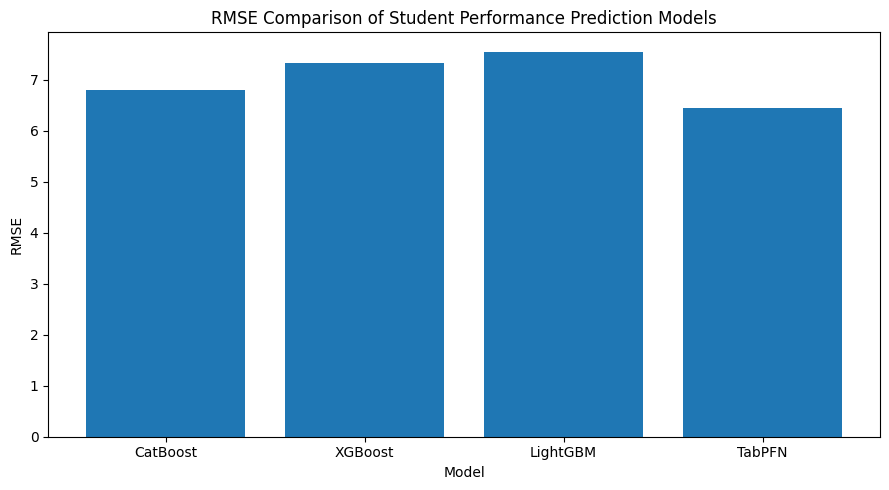

In [ ]:
# Model Performance Bar Chart :- 
# "This graph compares the RMSE values of the four models. Since RMSE is an error metric, the model with the lower RMSE provides better prediction performance."
plt.figure(figsize=(9, 5))

plt.bar(
    comparison_results["Model"],
    comparison_results["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")

plt.title(
    "RMSE Comparison of Student Performance Prediction Models"
)

plt.tight_layout()
plt.show()

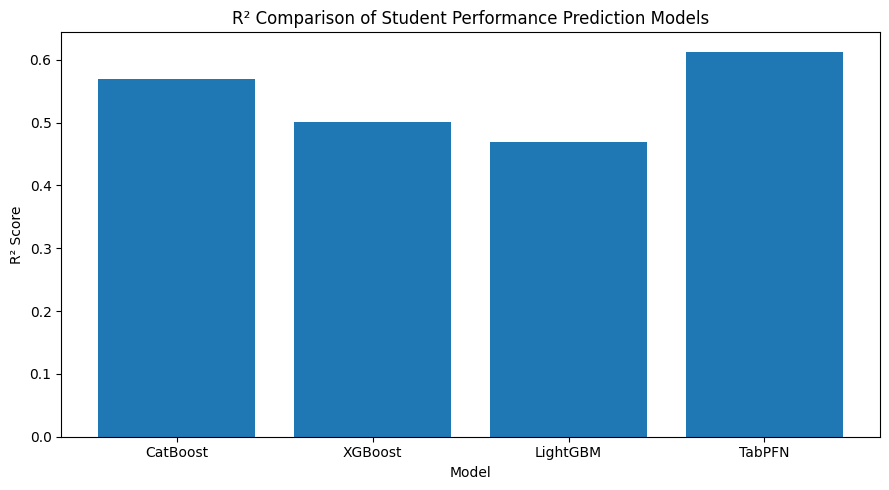

In [ ]:
# R² Comparison :-
# "R² indicates how well the model explains the variation in student performance. A higher R² indicates better predictive performance."
plt.figure(figsize=(9, 5))

plt.bar(
    comparison_results["Model"],
    comparison_results["R2"]
)

plt.xlabel("Model")
plt.ylabel("R² Score")

plt.title(
    "R² Comparison of Student Performance Prediction Models"
)

plt.tight_layout()
plt.show()

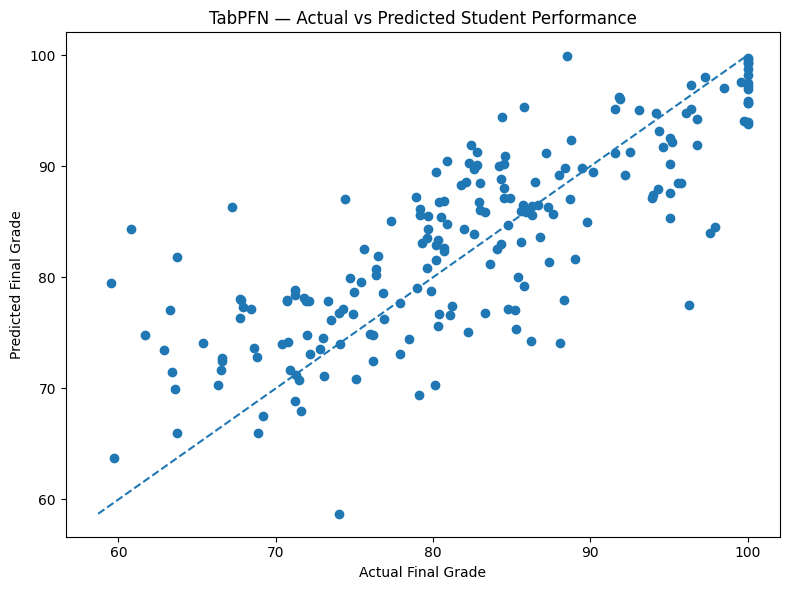

In [22]:
# TabPFN Actual vs Predicted
plt.figure(figsize=(8, 6))

plt.scatter(
    actual,
    predicted
)

min_value = min(
    actual.min(),
    predicted.min()
)

max_value = max(
    actual.max(),
    predicted.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")

plt.title(
    "TabPFN — Actual vs Predicted Student Performance"
)

plt.tight_layout()
plt.show()

In [23]:
# Calculate Prediction Error
tabpfn_predictions["Error"] = (
    tabpfn_predictions["Actual"]
    -
    tabpfn_predictions["Predicted"]
)

tabpfn_predictions["Absolute_Error"] = (
    tabpfn_predictions["Error"].abs()
)

display(
    tabpfn_predictions.head(10)
)

,Actual,Predicted,Absolute_Error,Error
0,71.8,78.146300,6.346300,-6.346300
1,66.6,72.488830,5.888830,-5.888830
2,62.9,73.430115,10.530115,-10.530115
3,95.2,92.228600,2.971400,2.971400
4,90.2,89.471405,0.728595,0.728595
5,63.6,69.941770,6.341770,-6.341770
6,96.8,94.276120,2.523880,2.523880
7,77.9,73.064026,4.835974,4.835974
8,66.5,71.654110,5.154110,-5.154110
9,59.7,63.745630,4.045630,-4.045630


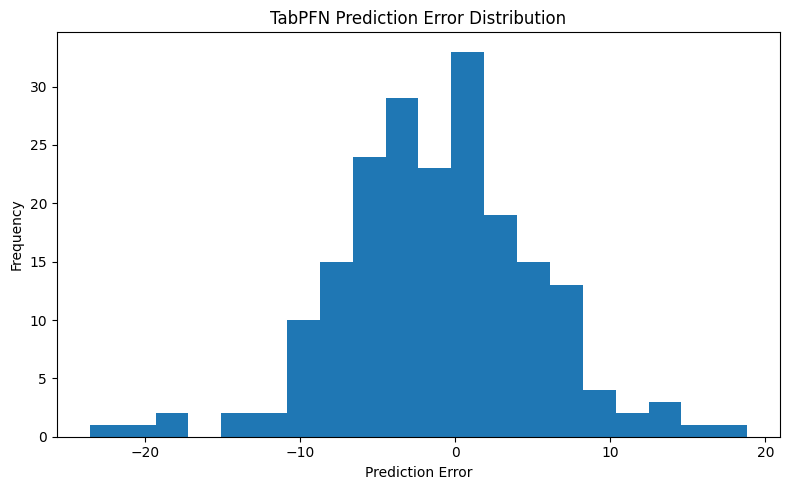

In [ ]:
# Error Distribution :-
# "This histogram shows how the prediction errors are distributed. Errors closer to zero indicate predictions closer to the actual student performance."
plt.figure(figsize=(8, 5))

plt.hist(
    tabpfn_predictions["Error"],
    bins=20
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.title(
    "TabPFN Prediction Error Distribution"
)

plt.tight_layout()
plt.show()

In [26]:
# Save Updated TabPFN Predictions
UPDATED_PREDICTION_PATH = (
    RESULTS_PATH /
    "tabpfn_predictions_with_error.csv"
)

tabpfn_predictions.to_csv(
    UPDATED_PREDICTION_PATH,
    index=False
)

print(
    "Updated TabPFN predictions saved:"
)

print(UPDATED_PREDICTION_PATH)

Updated TabPFN predictions saved:
d:\MCA Sem 3\RP\EduPredict-XAI\results\tabpfn_predictions_with_error.csv


In [28]:
# Final Evaluation Summary
print("=" * 70)
print("STEP 17 — MODEL EVALUATION COMPLETED")
print("=" * 70)

print("\nTabPFN Performance:")
print(f"MAE  : {tabpfn_mae:.4f}")
print(f"RMSE : {tabpfn_rmse:.4f}")
print(f"R²   : {tabpfn_r2:.4f}")

print("\nBest Model based on RMSE:")
print(best_model_row["Model"])

print("\nFiles created:")
print("✓ final_model_comparison.csv")
print("✓ model_ranking.csv")
print("✓ tabpfn_predictions_with_error.csv")


STEP 17 — MODEL EVALUATION COMPLETED

TabPFN Performance:
MAE  : 4.9842
RMSE : 6.4538
R²   : 0.6130

Best Model based on RMSE:
TabPFN

Files created:
✓ final_model_comparison.csv
✓ model_ranking.csv
✓ tabpfn_predictions_with_error.csv
